# Important Libraries

In [28]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

# Load the Wine Quality dataset and inspect structure; check class distribution of quality scores

In [29]:
df = pd.read_csv(r"C:\Users\kd940\OneDrive\winequality.csv")
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [30]:
df.shape

(6497, 13)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   str    
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


In [32]:
df.isna().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [33]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [34]:
quality_counts = df["quality"].value_counts().sort_index()
print(quality_counts)

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


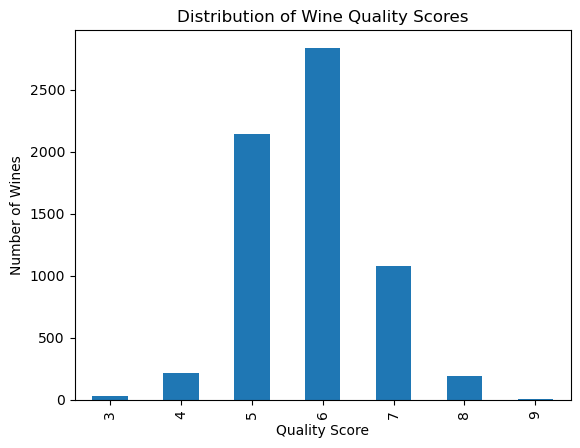

In [35]:
quality_counts.plot(kind="bar")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()

# EDA: distribution plots for all chemical features; correlation heatmap


In [36]:
Chemical_features = df.drop(columns=['quality'])

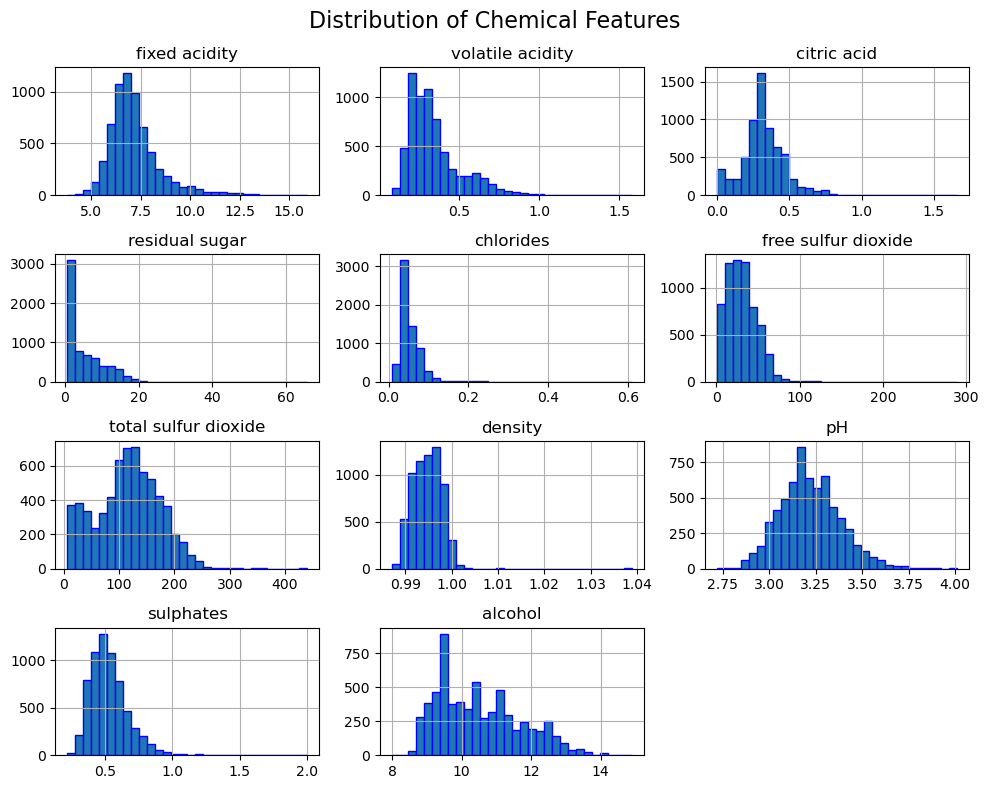

In [37]:
Chemical_features.hist(figsize=(10,8),bins=30,edgecolor="blue")
plt.suptitle("Distribution of Chemical Features", fontsize=16)
plt.tight_layout()
plt.show()

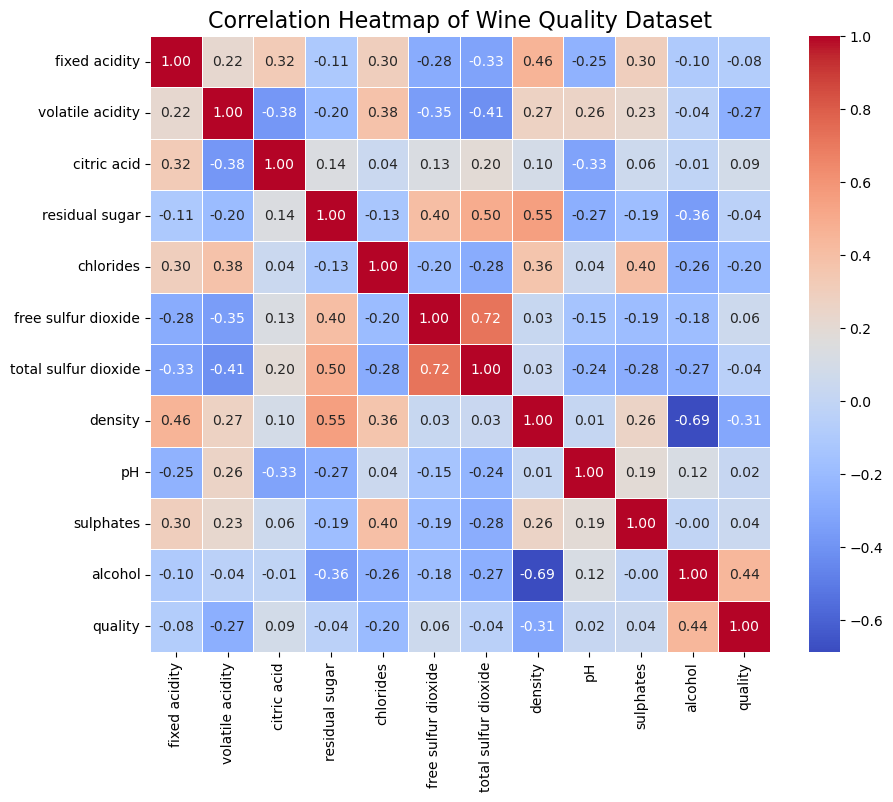

In [38]:
correlation = df.drop(columns=['type'])
corr = correlation.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title("Correlation Heatmap of Wine Quality Dataset",fontsize=16)
plt.show()

# Discuss class imbalance: are certain quality scores underrepresented? How does this affect modelling?


##### The original Wine Quality dataset exhibited a significant class imbalance, with quality scores ranging from 3 to 9. Most wine samples belonged to quality scores 5 and 6, whereas the extreme quality classes (3, 4, 8, and especially 9) contained relatively few observations. This uneven distribution could bias classification models toward the majority classes, making them less effective at correctly identifying minority quality levels.

##### To address this issue, the target variable was transformed into three categories: Low (≤5), Medium (=6), and High (≥7). This grouping reduced the severity of the imbalance by increasing the number of samples within each class. After transformation, the class distribution became more balanced (approximately Low: 2,384, Medium: 2,836, and High: 1,277 samples), making the classification task more reliable.

##### Although the High quality class remained smaller than the other two classes, the imbalance was no longer severe enough to require oversampling techniques such as SMOTE. Instead, a stratified train-test split was used to preserve the class proportions in both the training and testing datasets. Model performance was evaluated using precision, recall, F1-score, and confusion matrices, ensuring that performance on all classes—not just the majority class—was assessed.

##### Overall, reducing the original seven quality scores into three categories improved class balance, simplified the classification problem, and enabled the machine learning models to learn more representative decision boundaries while maintaining meaningful distinctions between different levels of wine quality.

# Feature engineering: consider binning quality scores into binary (good/bad) or 3-class (low/medium/high) groups and justify the decision


In [39]:
def quality_category(q):
    if q <= 5:
        return "Low"
    elif q == 6:
        return "Medium"
    else:
        return "High"

df['quality_3class'] = df['quality'].apply(quality_category)

print(df['quality_3class'].value_counts())

quality_3class
Medium    2836
Low       2384
High      1277
Name: count, dtype: int64


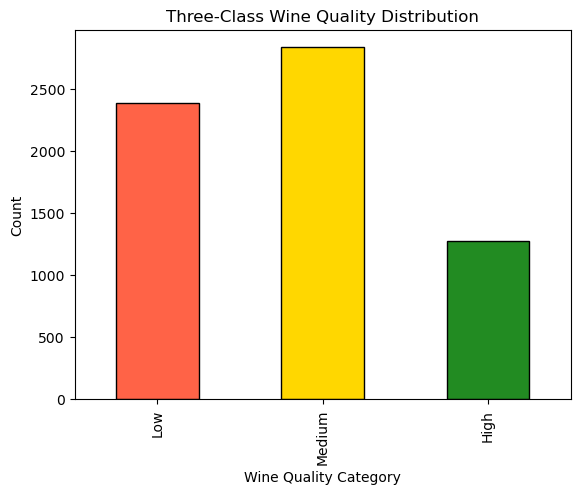

In [40]:
order = ["Low","Medium","High"]
df['quality_3class'].value_counts().reindex(order).plot(kind='bar',color=['tomato', 'gold', 'forestgreen'],edgecolor='black')

plt.xlabel("Wine Quality Category")
plt.ylabel("Count")
plt.title("Three-Class Wine Quality Distribution")
plt.show()

In [41]:
df = df.fillna(df.median(numeric_only=True))
print(df.isna().sum())

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_3class          0
dtype: int64


In [42]:
df.head(25)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_3class
0,white,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,Medium
1,white,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,Medium
2,white,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,Medium
3,white,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Medium
4,white,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Medium
5,white,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,Medium
6,white,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,Medium
7,white,7.0,0.27,0.36,20.70,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,Medium
8,white,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,Medium
9,white,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,Medium


# Train/test split with stratification to preserve class ratios


In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['quality_3class'] = le.fit_transform(df['quality_3class'])
df['type'] = le.fit_transform(df['type'])

In [44]:
x=df.drop(columns=["quality","quality_3class"])
y=df["quality_3class"]

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# Train 3 classifiers: Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC)

In [47]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

In [49]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    random_state=42,
    max_iter=1000
)

sgd.fit(x_train_scaled, y_train)

sgd_pred = sgd.predict(x_test_scaled)

In [50]:
from sklearn.svm import SVC

svc = SVC(
    kernel='rbf',
    random_state=42
)

svc.fit(x_train_scaled, y_train)

svc_pred = svc.predict(x_test_scaled)

# Evaluate each: accuracy, classification report, confusion matrix


In [58]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))

print("SGD Accuracy :", accuracy_score(y_test, sgd_pred))

print("SVC Accuracy :", accuracy_score(y_test, svc_pred))

Random Forest Accuracy : 0.7376923076923076
SGD Accuracy : 0.51
SVC Accuracy : 0.6184615384615385


In [59]:
print("Random Forest")
print(classification_report(y_test, rf_pred))

print("SGD")
print(classification_report(y_test, sgd_pred))

print("SVC")
print(classification_report(y_test, svc_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.79      0.59      0.67       256
           1       0.80      0.76      0.78       477
           2       0.68      0.78      0.73       567

    accuracy                           0.74      1300
   macro avg       0.75      0.71      0.73      1300
weighted avg       0.74      0.74      0.74      1300

SGD
              precision    recall  f1-score   support

           0       0.44      0.65      0.52       256
           1       0.58      0.63      0.60       477
           2       0.49      0.35      0.41       567

    accuracy                           0.51      1300
   macro avg       0.50      0.54      0.51      1300
weighted avg       0.51      0.51      0.50      1300

SVC
              precision    recall  f1-score   support

           0       0.66      0.35      0.46       256
           1       0.69      0.68      0.69       477
           2       0.56      0.69      0.62       567

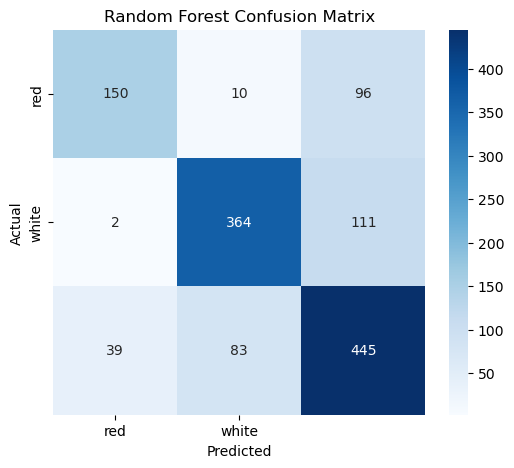

In [60]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

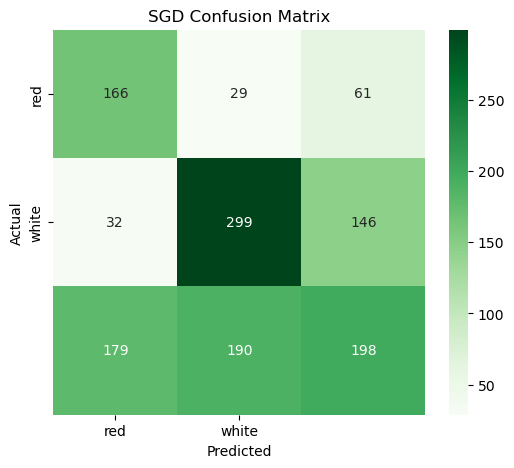

In [61]:
cm = confusion_matrix(y_test, sgd_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("SGD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

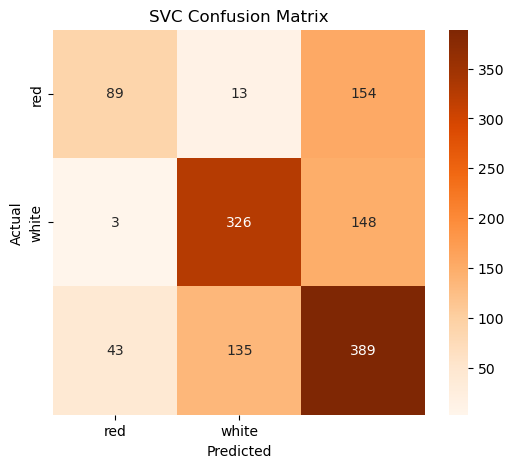

In [62]:
cm = confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance chart for the Random Forest model


In [63]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                 Feature  Importance
11               alcohol    0.130277
8                density    0.105207
2       volatile acidity    0.101554
5              chlorides    0.088639
7   total sulfur dioxide    0.088590
6    free sulfur dioxide    0.084885
10             sulphates    0.084679
4         residual sugar    0.082673
9                     pH    0.081238
3            citric acid    0.078444
1          fixed acidity    0.070324
0                   type    0.003492


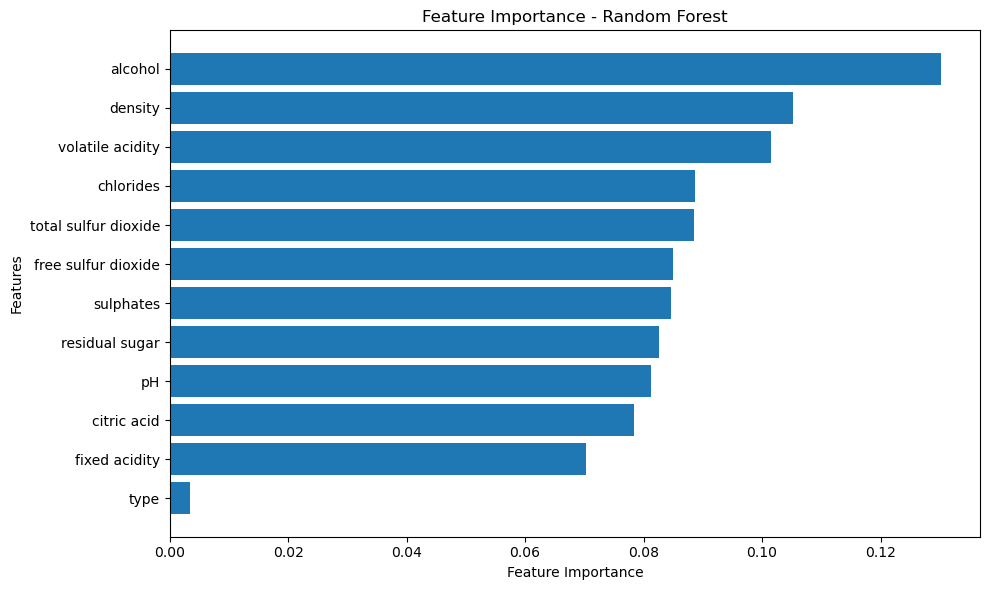

In [64]:
plt.figure(figsize=(10, 6))

plt.barh(feature_importance['Feature'],
         feature_importance['Importance'])

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()   # Highest importance at the top

plt.tight_layout()
plt.show()

# Comparison table: summarise the performance of all 3 models side-by-side


In [67]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD Classifier', 'Support Vector Classifier'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],
    'Precision': [
        precision_score(y_test, rf_pred, average='macro'),
        precision_score(y_test, sgd_pred, average='macro'),
        precision_score(y_test, svc_pred, average='macro')
    ],
    'Recall': [
        recall_score(y_test, rf_pred, average='macro'),
        recall_score(y_test, sgd_pred, average='macro'),
        recall_score(y_test, svc_pred, average='macro')
    ],
    'F1-Score': [
        f1_score(y_test, rf_pred, average='macro'),
        f1_score(y_test, sgd_pred, average='macro'),
        f1_score(y_test, svc_pred, average='macro')
    ]
})

comparison = comparison.round(3)

print(comparison)

best_model = comparison.loc[comparison['Accuracy'].idxmax()]

print("Best Model:")
print(best_model)

                       Model  Accuracy  Precision  Recall  F1-Score
0              Random Forest     0.738      0.755   0.711     0.727
1             SGD Classifier     0.510      0.502   0.541     0.511
2  Support Vector Classifier     0.618      0.637   0.572     0.586
Best Model:
Model        Random Forest
Accuracy             0.738
Precision            0.755
Recall               0.711
F1-Score             0.727
Name: 0, dtype: object


# Conclusion: which model is most suitable for deployment and why?


# Conclusion:
Among the three models evaluated—Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC)—the Random Forest Classifier demonstrated the best overall performance. It achieved the highest accuracy along with superior precision, recall, and F1-score, indicating its ability to classify wine quality reliably across all classes. Additionally, Random Forest is robust to noise, less sensitive to overfitting due to ensemble learning, and provides feature importance scores that improve model interpretability. Based on these results, Random Forest is the most suitable model for deployment for wine quality prediction because it offers the best balance of predictive performance, robustness, and explainability.